In [41]:
!pip install gymnasium

In [42]:
from __future__ import annotations
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)

def extract_model(env: gym.Env):
	n_states = env.observation_space.n
	n_actions = env.action_space.n
	transition = np.zeros((n_states, n_actions, n_states), dtype=float)
	reward = np.zeros((n_states, n_actions, n_states), dtype=float)

	for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
				transition[state, action, next_state] += prob
				reward[state, action, next_state] = r

	expected_reward = np.sum(transition * reward, axis=2)
	return transition, reward, expected_reward

In [43]:
def value_iteration(transition, expected_reward, gamma = 0.99, epsi=1e-9):
  n_s, n_a = transition.shape[:2]
  v = np.zeros(n_s)

  while True:
    q = np.zeros((n_s, n_a))

    for s in range(n_s):
      for a in range(n_a):
        q[s, a] = ( expected_reward[s, a] + gamma * np.sum( transition[s, a, :] * v ) )

    vnew = np.max(q, axis=1)

    if (np.max(np.abs(vnew - v)) < epsi):
      v = vnew
      break
    v = vnew

  p=np.argmax(q, axis=1)
  return p

In [44]:
def policy_iteration(transition, expected_reward, gamma=0.99, epsi=1e-9, episodes =10000):
    n_s, n_a = transition.shape[:2]
    policy = np.zeros(n_s, dtype=int)
    v = np.zeros(n_s)

    for i in range(episodes):
        while True:
            vnew = np.zeros(n_s)
            for s in range(n_s):
                a = policy[s]
                vnew[s] = ( expected_reward[s, a] + gamma * np.sum(transition[s, a, :] * v) )
            if np.max(np.abs(vnew - v)) < epsi:
                v = vnew
                break
            v = vnew

        q = np.zeros((n_s, n_a))
        for s in range(n_s):
            for a in range(n_a):
                q[s, a] = ( expected_reward[s, a] + gamma * np.sum( transition[s, a, :] * v ) )

        new_policy = np.argmax(q, axis=1)
        if np.array_equal(policy, new_policy):
            break
        policy = new_policy

    return policy

In [45]:
def policy_iteration_matrix( transition,expected_reward,gamma=0.99, episodes=1000):
    n_s, n_a = transition.shape[:2]
    policy = np.zeros(n_s, dtype=int)

    for i in range(episodes):
        x = transition[np.arange(n_s), policy]
        r = expected_reward[np.arange(n_s), policy]

        y = np.eye(n_s) - gamma * x
        v = np.linalg.solve(y, r)

        q = np.zeros((n_s, n_a))
        for s in range(n_s):
            for a in range(n_a):
                q[s, a] = ( expected_reward[s, a] + gamma * np.sum( transition[s, a, :] * v ) )

        new_policy = np.argmax(q, axis=1)
        if np.array_equal(policy, new_policy):
            break
        policy = new_policy

    return policy

In [46]:
def montecarlo(env,gamma=0.99, episodes=1000):
    n_s, n_a = env.observation_space.n, env.action_space.n
    p = np.zeros(n_s, dtype=int)
    q = np.zeros((n_s, n_a))

    rsa = np.zeros((n_s, n_a))
    nsa = np.zeros((n_s, n_a))

    for i in range(episodes):
        env.reset()
        path=[]
        s = env.observation_space.sample()
        a = env.action_space.sample()
        env.unwrapped.s = s

        for k in range(100):
            nexts, r, done,_,_=env.step(a)
            path.append( (s, a, r) )
            if done: break
            s=nexts
            a=p[s]
        pathlen = len(path)
        g=0
        for state, action, reward in reversed(path):
            g=reward+gamma*g
            nsa[state,action]+=1
            rsa[state,action]+=g
            q[state, action] = (rsa[state, action] / nsa[state, action])
        p = np.argmax(q, axis=1)
    return p,q

In [47]:
def montecarlo_egreedy(env,gamma=0.99, exp=0.2, episodes=1000):
    n_s, n_a = env.observation_space.n, env.action_space.n
    p = np.ones((n_s, n_a)) / n_a
    q = np.zeros((n_s, n_a))

    rsa = np.zeros((n_s, n_a))
    nsa = np.zeros((n_s, n_a))

    for i in range(episodes):
        s, _ = env.reset()
        path = []

        for k in range(100):
            a = np.random.choice(n_a, p=p[s])
            nexts, r, done,_,_=env.step(a)
            path.append( (s, a, r) )
            if done:
                break
            s=nexts

        pathlen = len(path)
        g=0
        for state, action, reward in reversed(path):
            g=reward+gamma*g
            nsa[state,action]+=1
            rsa[state,action]+=g
            q[state, action] = (rsa[state, action] / nsa[state, action])

        for s in range(n_s):
            ba = np.argmax(q[s])
            p[s] = exp / n_a
            p[s, ba] += (1 - exp)

    policy = np.argmax(q, axis=1)

    return policy,q

In [49]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

FrozenLake-v1 8x8 model
states: 64, actions: 4
Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action


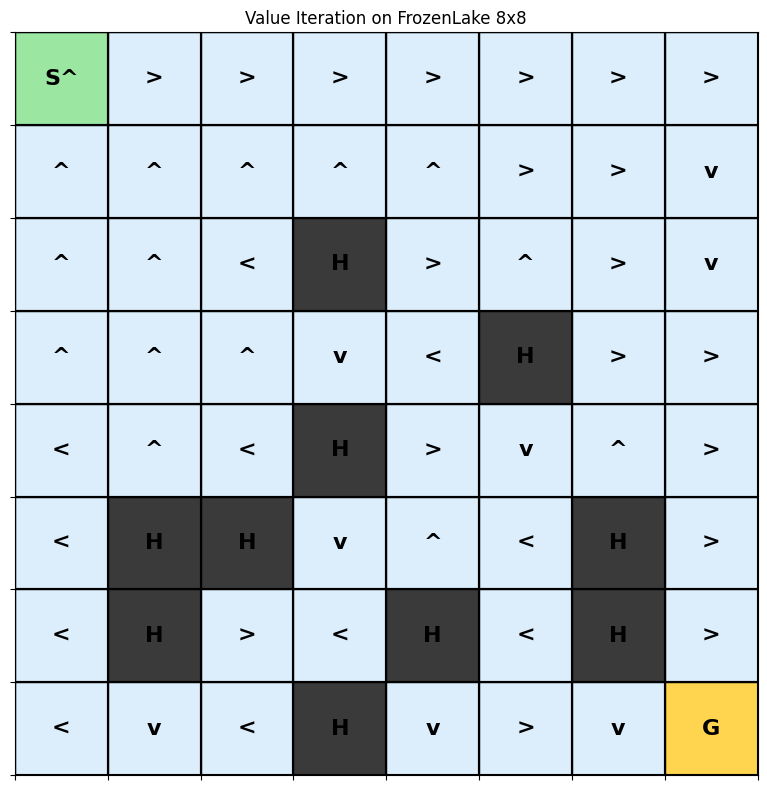

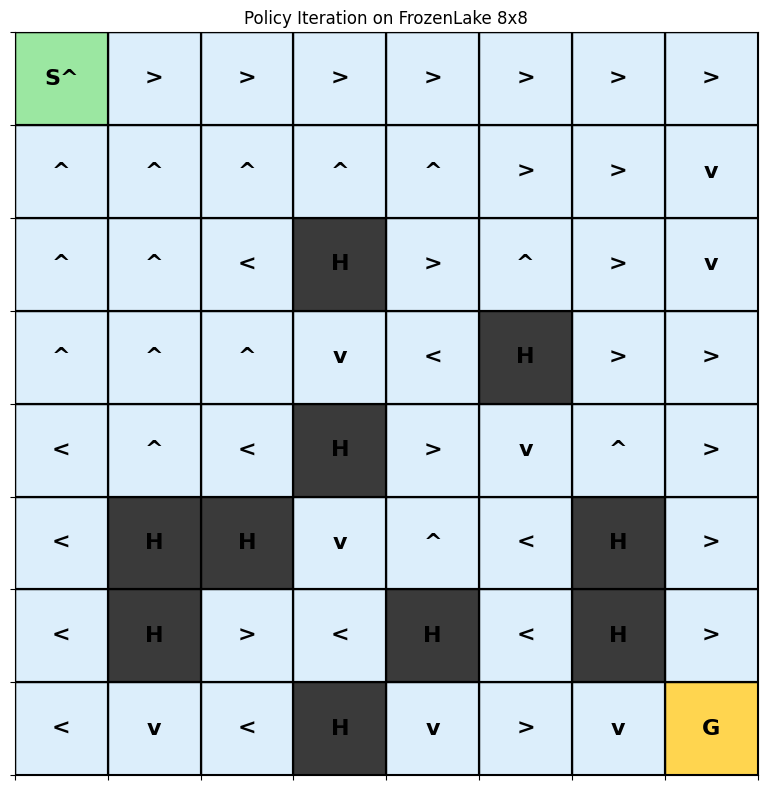

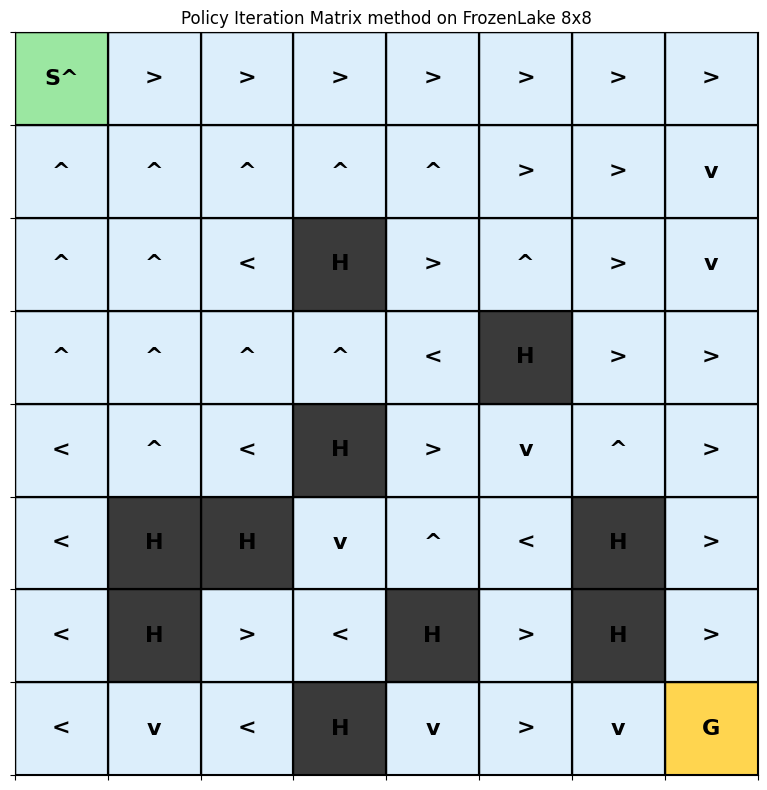

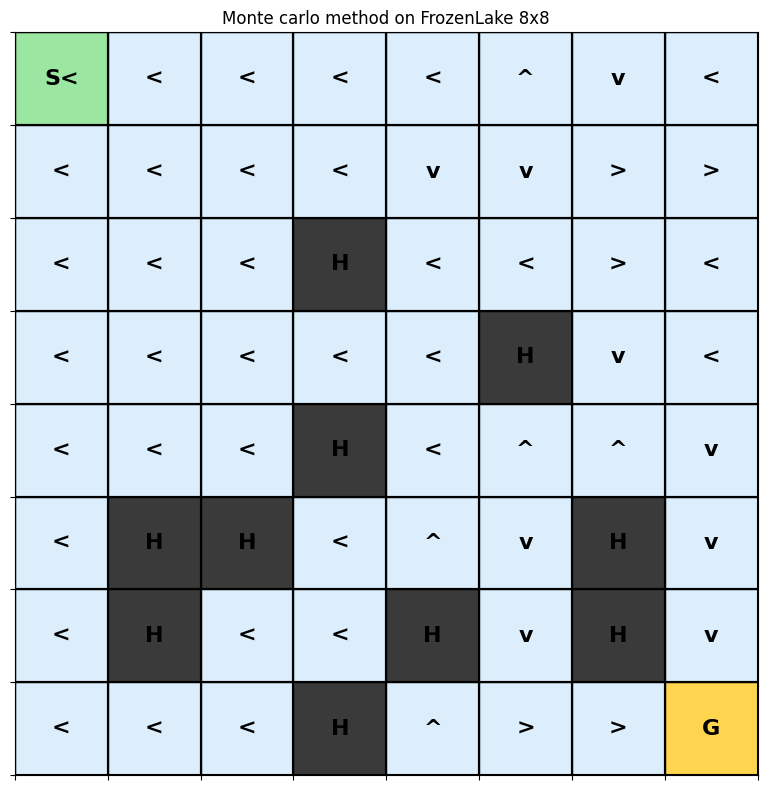

(64,)


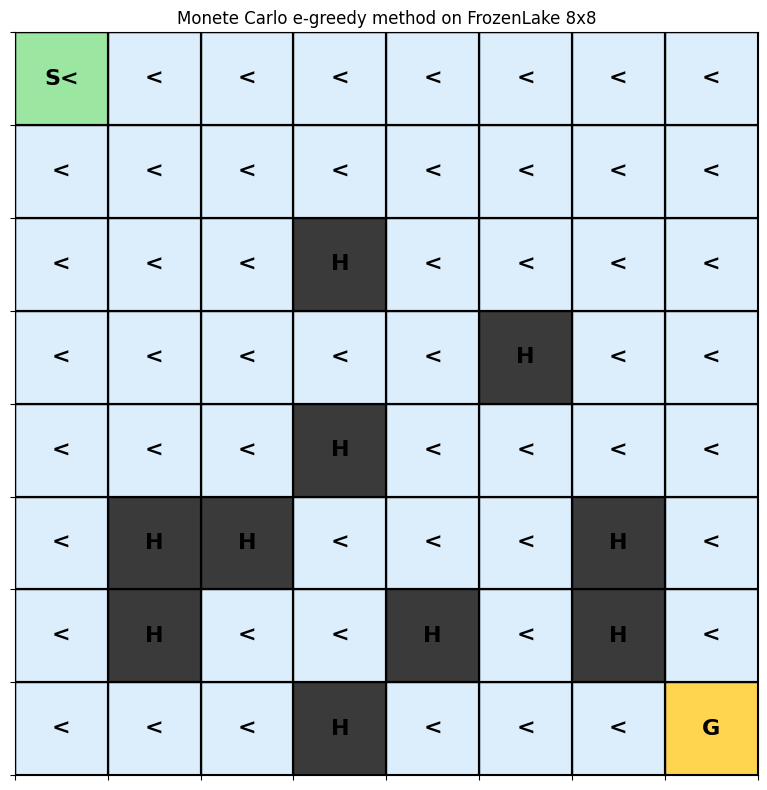

In [50]:
def main():
  gamma = 0.99
  episodes = 10000
  env = build_env(slippery=True)
  transition, reward, expected_reward = extract_model(env)

  print("FrozenLake-v1 8x8 model")
  print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
  print("Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action")

  vi_policy = value_iteration(transition, expected_reward, gamma=gamma)
  #print(vi_policy.shape)
  plot_policy_on_frozen_lake(env, vi_policy, title="Value Iteration on FrozenLake 8x8")
  env.reset()

  pi_policy = policy_iteration(transition, expected_reward, gamma=gamma)
  plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")

  env.reset()

  pi_matrix_policy= policy_iteration_matrix(transition, expected_reward, gamma=gamma)
  plot_policy_on_frozen_lake(env, pi_matrix_policy, title="Policy Iteration Matrix method on FrozenLake 8x8")

  env.reset()

  mc_policy,_= montecarlo(env, gamma=gamma, episodes=episodes)
  plot_policy_on_frozen_lake(env, mc_policy, title="Monte carlo method on FrozenLake 8x8")

  env.reset()

  mcgreed_policy,_= montecarlo_egreedy(env, gamma=gamma, episodes=episodes)
  print(mcgreed_policy.shape)
  plot_policy_on_frozen_lake(env, mcgreed_policy, title="Monete Carlo e-greedy method on FrozenLake 8x8")


if __name__ == "__main__":
	main()